# Linear Probing per Layer

**Core question:** freeze the representation at each layer, train a linear classifier on top,
and plot accuracy vs depth. If probe accuracy keeps climbing through the middle layers, those
small residual updates are still building task-relevant features. If it plateaus while updates
continue, the middle layers are doing something else.

**Method**
- Extract per-layer token representations (CLS by default) for a labelled probe dataset.
- Fit a standardized multinomial logistic-regression probe per layer; evaluate top-1 accuracy on a
  held-out split.
- Plot accuracy vs depth and the per-layer accuracy gain (where information is actually added).

**Dataset note:** probing needs many labelled samples per class, so this uses a dedicated probe
dataset (CIFAR-100 by default) rather than the 1,024-sample calibration set used in the other
notebooks. It must be a *script-free* (parquet-backed) dataset, since the current `datasets`
library no longer runs dataset loading scripts (so e.g. `frgfm/imagenette` fails). Swap
`probe_dataset_*` in the config for another parquet dataset (or full ImageNet validation if you
have access) to change granularity; `probe_dataset_fallbacks` is tried in order if the primary
fails to load. Note CIFAR-100 is 32px upscaled to the model's input size, so absolute accuracy is
modest — the **shape of the accuracy-vs-depth curve** is what matters here, not the absolute level.


In [1]:
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import (
    AutoImageProcessor,
    DeiTForImageClassificationWithTeacher,
    ViTForImageClassification,
)

sns.set_theme(style="whitegrid")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = choose_device()
print(f"Using device: {device}")


@dataclass(frozen=True)
class ModelSpec:
    name: str
    repo_id: str
    imagenet_top1: float
    imagenet_top5: float
    params: str
    is_distilled: bool = False


MODEL_SPECS: List[ModelSpec] = [
    ModelSpec("DeiT-tiny", "facebook/deit-tiny-patch16-224", 72.2, 91.1, "5M"),
    ModelSpec("DeiT-small", "facebook/deit-small-patch16-224", 79.9, 95.0, "22M"),
    ModelSpec("DeiT-base", "facebook/deit-base-patch16-224", 81.8, 95.6, "86M"),
    ModelSpec("DeiT-tiny distilled", "facebook/deit-tiny-distilled-patch16-224", 74.5, 91.9, "6M", True),
    ModelSpec("DeiT-small distilled", "facebook/deit-small-distilled-patch16-224", 81.2, 95.4, "22M", True),
    ModelSpec("DeiT-base distilled", "facebook/deit-base-distilled-patch16-224", 83.4, 96.5, "87M", True),
    ModelSpec("DeiT-base 384", "facebook/deit-base-patch16-384", 82.9, 96.2, "87M"),
    ModelSpec("DeiT-base distilled 384", "facebook/deit-base-distilled-patch16-384", 85.2, 97.2, "88M", True),
]


Using device: cuda


In [2]:
def slugify(value: str) -> str:
    return value.lower().replace("-", "_").replace(" ", "_")


def select_model_specs(selected_names: Optional[Sequence[str]] = None) -> List[ModelSpec]:
    if not selected_names:
        return MODEL_SPECS
    selected_name_set = set(selected_names)
    selected = [spec for spec in MODEL_SPECS if spec.name in selected_name_set]
    missing = sorted(selected_name_set - {spec.name for spec in selected})
    if missing:
        raise ValueError(f"Unknown model names: {missing}")
    return selected


def get_model_class(spec: ModelSpec):
    if spec.is_distilled:
        return DeiTForImageClassificationWithTeacher
    return ViTForImageClassification


def get_base_model(model):
    prefix = getattr(model, "base_model_prefix", None)
    if prefix and hasattr(model, prefix):
        return getattr(model, prefix)
    for attr in ("deit", "vit", "model"):
        if hasattr(model, attr):
            return getattr(model, attr)
    return model


def get_layer_stack(model):
    base = get_base_model(model)
    encoder = getattr(base, "encoder", None)
    if encoder is not None:
        if hasattr(encoder, "layer"):
            return encoder.layer
        if hasattr(encoder, "layers"):
            return encoder.layers
    # Version-robust fallback: the largest ModuleList of repeated transformer blocks.
    best = None
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.ModuleList) and len(module) >= 2:
            if best is None or len(module) > len(best):
                best = module
    if best is None:
        raise AttributeError("Could not locate the transformer block list.")
    return best


def cleanup_model(*objects) -> None:
    for obj in objects:
        del obj
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def load_model_and_processor(spec: ModelSpec):
    processor = AutoImageProcessor.from_pretrained(spec.repo_id, use_fast=True)
    model_cls = get_model_class(spec)
    model = model_cls.from_pretrained(spec.repo_id)
    model = model.to(device).eval()
    return model, processor


def get_extraction_batch_size(spec: ModelSpec, config: Dict) -> int:
    if "384" in spec.repo_id:
        return config.get("extraction_batch_size_384", config["extraction_batch_size"])
    return config["extraction_batch_size"]


def sample_dataset(dataset_split, max_samples: int, seed: int):
    total_samples = min(max_samples, len(dataset_split))
    shuffled = dataset_split.shuffle(seed=seed)
    return shuffled.select(range(total_samples))


def detect_columns(dataset_split):
    columns = dataset_split.column_names
    image_col = next((c for c in ("image", "img", "image_url") if c in columns), None)
    if image_col is None:
        image_col = next((c for c in columns if "image" in c or "img" in c), None)
    label_col = next((c for c in ("label", "fine_label", "labels", "class") if c in columns), None)
    if label_col is None:
        label_col = next((c for c in columns if "label" in c or "class" in c), None)
    if image_col is None or label_col is None:
        raise ValueError(f"Could not auto-detect image/label columns from {columns}.")
    return image_col, label_col


def extract_token_representation(hidden_state: torch.Tensor, token_representation: str) -> torch.Tensor:
    if token_representation == "cls":
        token_state = hidden_state[:, 0, :]
    elif token_representation == "mean_all":
        token_state = hidden_state.mean(dim=1)
    elif token_representation == "mean_non_cls":
        token_state = hidden_state[:, 1:, :].mean(dim=1)
    else:
        raise ValueError(f"Unsupported token representation: {token_representation}")
    return token_state.detach().to("cpu", dtype=torch.float32)


In [3]:
@torch.inference_mode()
def collect_layer_features(model, processor, dataset_split, image_col, label_col, batch_size,
                           token_representation="cls", show_progress=True):
    layer_buffers: Optional[List[List[torch.Tensor]]] = None
    labels: List[int] = []

    iterator = range(0, len(dataset_split), batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Encoding images", leave=False)

    for start_idx in iterator:
        batch = dataset_split[start_idx : start_idx + batch_size]
        images = [image.convert("RGB") for image in batch[image_col]]
        labels.extend(int(label) for label in batch[label_col])
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}

        outputs = model(**inputs, output_hidden_states=True)
        if outputs.hidden_states is None:
            raise ValueError("Model did not return hidden states.")
        token_states = [extract_token_representation(h, token_representation) for h in outputs.hidden_states]

        if layer_buffers is None:
            layer_buffers = [[] for _ in token_states]
        for layer_idx, token_state in enumerate(token_states):
            layer_buffers[layer_idx].append(token_state)

        del outputs, token_states, inputs
        if device.type == "cuda":
            torch.cuda.empty_cache()

    features = [torch.cat(chunks, dim=0).numpy() for chunks in layer_buffers]
    return features, np.asarray(labels)


def train_probe(train_features, train_labels, test_features, test_labels, config):
    classifier = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=config["probe_C"], max_iter=config["probe_max_iter"]),
    )
    classifier.fit(train_features, train_labels)
    train_accuracy = round(100.0 * classifier.score(train_features, train_labels), 2)
    test_accuracy = round(100.0 * classifier.score(test_features, test_labels), 2)
    return train_accuracy, test_accuracy


def run_probing_for_spec(spec: ModelSpec, train_ds, test_ds, image_col, label_col, config) -> pd.DataFrame:
    print(f"Running linear probing for {spec.name}...")
    model, processor = load_model_and_processor(spec)
    batch_size = get_extraction_batch_size(spec, config)
    token_representation = config.get("token_representation", "cls")

    train_features, train_labels = collect_layer_features(
        model, processor, train_ds, image_col, label_col, batch_size,
        token_representation=token_representation, show_progress=config["show_progress"],
    )
    test_features, test_labels = collect_layer_features(
        model, processor, test_ds, image_col, label_col, batch_size,
        token_representation=token_representation, show_progress=config["show_progress"],
    )
    num_classes = int(max(train_labels.max(), test_labels.max())) + 1

    rows = []
    layer_iterator = range(len(train_features))
    if config["show_progress"]:
        layer_iterator = tqdm(layer_iterator, desc=f"Probing {spec.name}", leave=False)
    for layer_idx in layer_iterator:
        train_accuracy, test_accuracy = train_probe(
            train_features[layer_idx], train_labels, test_features[layer_idx], test_labels, config
        )
        rows.append({
            "model_name": spec.name,
            "repo_id": spec.repo_id,
            "token_representation": token_representation,
            "layer": layer_idx,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
            "num_classes": num_classes,
            "train_size": len(train_labels),
            "test_size": len(test_labels),
        })

    cleanup_model(model, processor, train_features, test_features)
    return pd.DataFrame(rows)


In [4]:
def load_probe_splits(config):
    candidates = [(
        config["probe_dataset_name"],
        config.get("probe_dataset_config"),
        config["probe_train_split"],
        config["probe_test_split"],
    )]
    candidates += [tuple(entry) for entry in config.get("probe_dataset_fallbacks", [])]

    train_ds = test_ds = None
    last_error = None
    for name, cfg, train_split, test_split in candidates:
        try:
            train_ds = load_dataset(name, cfg, split=train_split)
            test_ds = load_dataset(name, cfg, split=test_split)
            print(f"Loaded probe dataset {name!r} (config={cfg!r}).")
            break
        except Exception as exc:  # noqa: BLE001 - fall through to the next candidate dataset
            print(f"  could not load {name!r}: {type(exc).__name__}: {exc}")
            train_ds = test_ds = None
            last_error = exc

    if train_ds is None or test_ds is None:
        raise RuntimeError(f"Could not load any probe dataset. Last error: {last_error}")

    train_ds = sample_dataset(train_ds, config["max_train_samples"], config["seed"])
    test_ds = sample_dataset(test_ds, config["max_test_samples"], config["seed"])
    return train_ds, test_ds


def run_probing_suite(model_specs: Sequence[ModelSpec], train_ds, test_ds, config: Dict) -> pd.DataFrame:
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)
    image_col, label_col = detect_columns(train_ds)
    print(f"Probe columns -> image: {image_col!r}, label: {label_col!r}")

    frames = []
    for spec in model_specs:
        frame = run_probing_for_spec(spec, train_ds, test_ds, image_col, label_col, config)
        frame.to_csv(results_dir / f"{slugify(spec.name)}_linear_probe.csv", index=False)
        frames.append(frame)

    results_df = pd.concat(frames, ignore_index=True)
    results_df.to_csv(results_dir / "linear_probe_all_models.csv", index=False)
    return results_df


def plot_probe_accuracy_comparison(results_df, model_specs, metric="test_accuracy"):
    model_names = [spec.name for spec in model_specs]
    palette = sns.color_palette("tab10", n_colors=len(model_names))
    plt.figure(figsize=(13, 8))
    for color, model_name in zip(palette, model_names):
        d = results_df[results_df["model_name"] == model_name].sort_values("layer")
        if d.empty:
            continue
        plt.plot(d["layer"], d[metric], marker="o", linewidth=2, color=color, label=model_name)
    plt.title(f"Linear probe {metric} vs depth")
    plt.xlabel("Layer (0 = embeddings, L = final)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()


def plot_probe_report(results_df, model_specs, models_per_figure=8, n_cols=4):
    model_names = [spec.name for spec in model_specs]
    for start in range(0, len(model_names), models_per_figure):
        batch = model_names[start : start + models_per_figure]
        n_rows = int(np.ceil(len(batch) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.9 * n_cols, 3.5 * n_rows), squeeze=False)
        flat_axes = axes.flatten()
        for ax, model_name in zip(flat_axes, batch):
            d = results_df[results_df["model_name"] == model_name].sort_values("layer")
            if d.empty:
                ax.set_visible(False)
                continue
            ax.plot(d["layer"], d["test_accuracy"], marker="o", color="#1f77b4", label="test")
            ax.plot(d["layer"], d["train_accuracy"], marker="s", color="#ff7f0e", alpha=0.6, label="train")
            ax.set_title(model_name)
            ax.set_xlabel("Layer")
            ax.set_ylabel("Accuracy (%)")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        for ax in flat_axes[len(batch):]:
            ax.set_visible(False)
        plt.suptitle(f"Linear probe accuracy ({start + 1}-{start + len(batch)} of {len(model_names)} models)", y=1.0)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()


def plot_probe_layer_gain(results_df, model_specs, metric="test_accuracy"):
    model_names = [spec.name for spec in model_specs]
    palette = sns.color_palette("tab10", n_colors=len(model_names))
    plt.figure(figsize=(13, 8))
    for color, model_name in zip(palette, model_names):
        d = results_df[results_df["model_name"] == model_name].sort_values("layer")
        if d.empty:
            continue
        gain = d[metric].diff()
        plt.plot(d["layer"], gain, marker="o", linewidth=2, color=color, label=model_name)
    plt.axhline(0, color="gray", linestyle="--", alpha=0.6)
    plt.title(f"Per-layer probe accuracy gain (delta {metric}) - where features are added")
    plt.xlabel("Layer")
    plt.ylabel("Accuracy gain vs previous layer (pts)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()


In [5]:
EXPERIMENT_CONFIG = {
    # Probe dataset (needs many labelled samples per class). Must be script-free (parquet-backed):
    # the newer `datasets` no longer runs dataset loading scripts, so e.g. frgfm/imagenette fails.
    "probe_dataset_name": "uoft-cs/cifar100",
    "probe_dataset_config": None,
    "probe_train_split": "train",
    "probe_test_split": "test",
    # Tried in order if the primary fails to load (name, config, train_split, test_split):
    "probe_dataset_fallbacks": [
        ("uoft-cs/cifar10", None, "train", "test"),
    ],
    "selected_model_names": [spec.name for spec in MODEL_SPECS],
    "max_train_samples": 4000,
    "max_test_samples": 2000,
    "extraction_batch_size": 16,
    "extraction_batch_size_384": 4,
    "token_representation": "cls",
    "probe_C": 1.0,
    "probe_max_iter": 2000,
    "seed": 0,
    "results_dir": "standardized_results",
    "show_progress": True,
}


In [6]:
selected_specs = select_model_specs(EXPERIMENT_CONFIG["selected_model_names"])
train_ds, test_ds = load_probe_splits(EXPERIMENT_CONFIG)

print(f"Probe train: {len(train_ds):,} | test: {len(test_ds):,}")
pd.DataFrame([asdict(spec) for spec in selected_specs])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loaded probe dataset 'uoft-cs/cifar100' (config=None).
Probe train: 4,000 | test: 2,000


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [7]:
probe_results_df = run_probing_suite(selected_specs, train_ds, test_ds, EXPERIMENT_CONFIG)
probe_results_df.head()


Probe columns -> image: 'img', label: 'fine_label'
Running linear probing for DeiT-tiny...


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/1000 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/500 [00:00<?, ?it/s]

Probing DeiT-base distilled 384:   0%|          | 0/13 [00:00<?, ?it/s]

,model_name,repo_id,token_representation,layer,train_accuracy,test_accuracy,num_classes,train_size,test_size
0,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,0,1.27,1.15,100,4000,2000
1,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,1,32.35,14.20,100,4000,2000
2,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,2,54.30,24.20,100,4000,2000
3,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,3,69.73,29.05,100,4000,2000
4,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,4,89.65,31.75,100,4000,2000


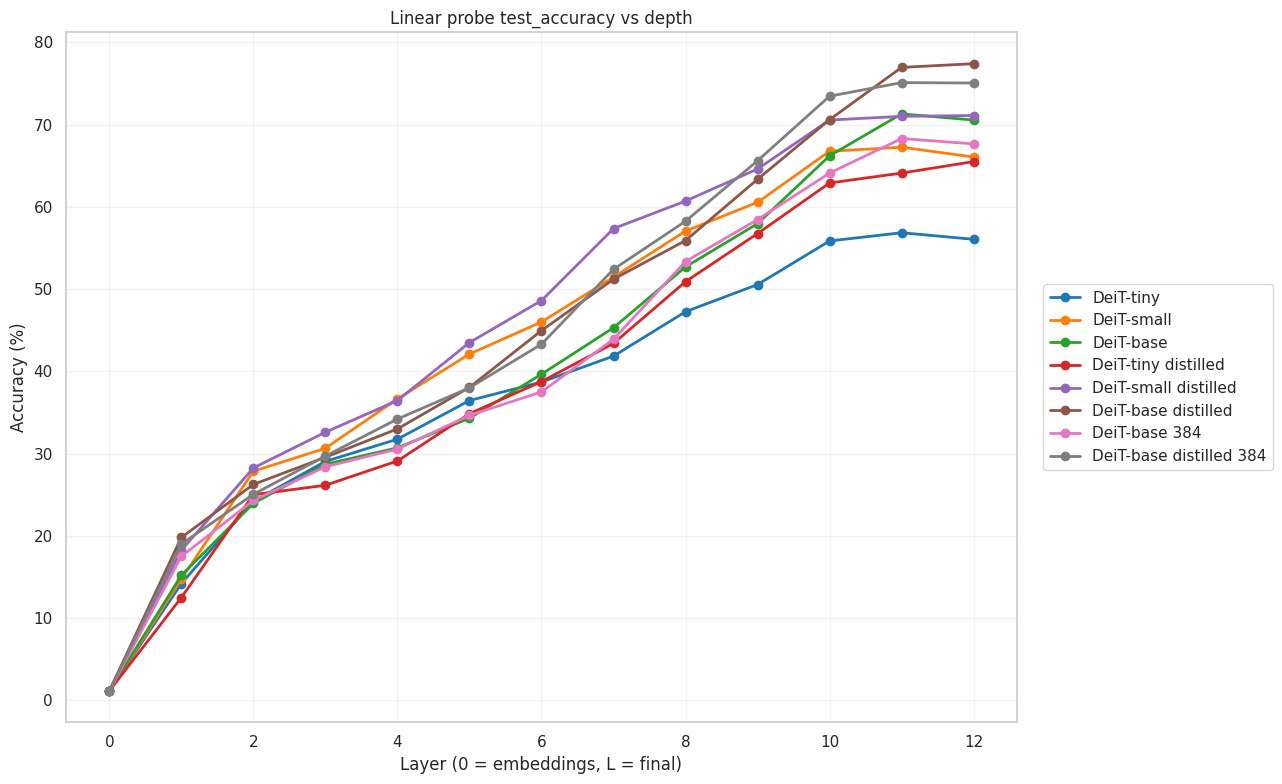

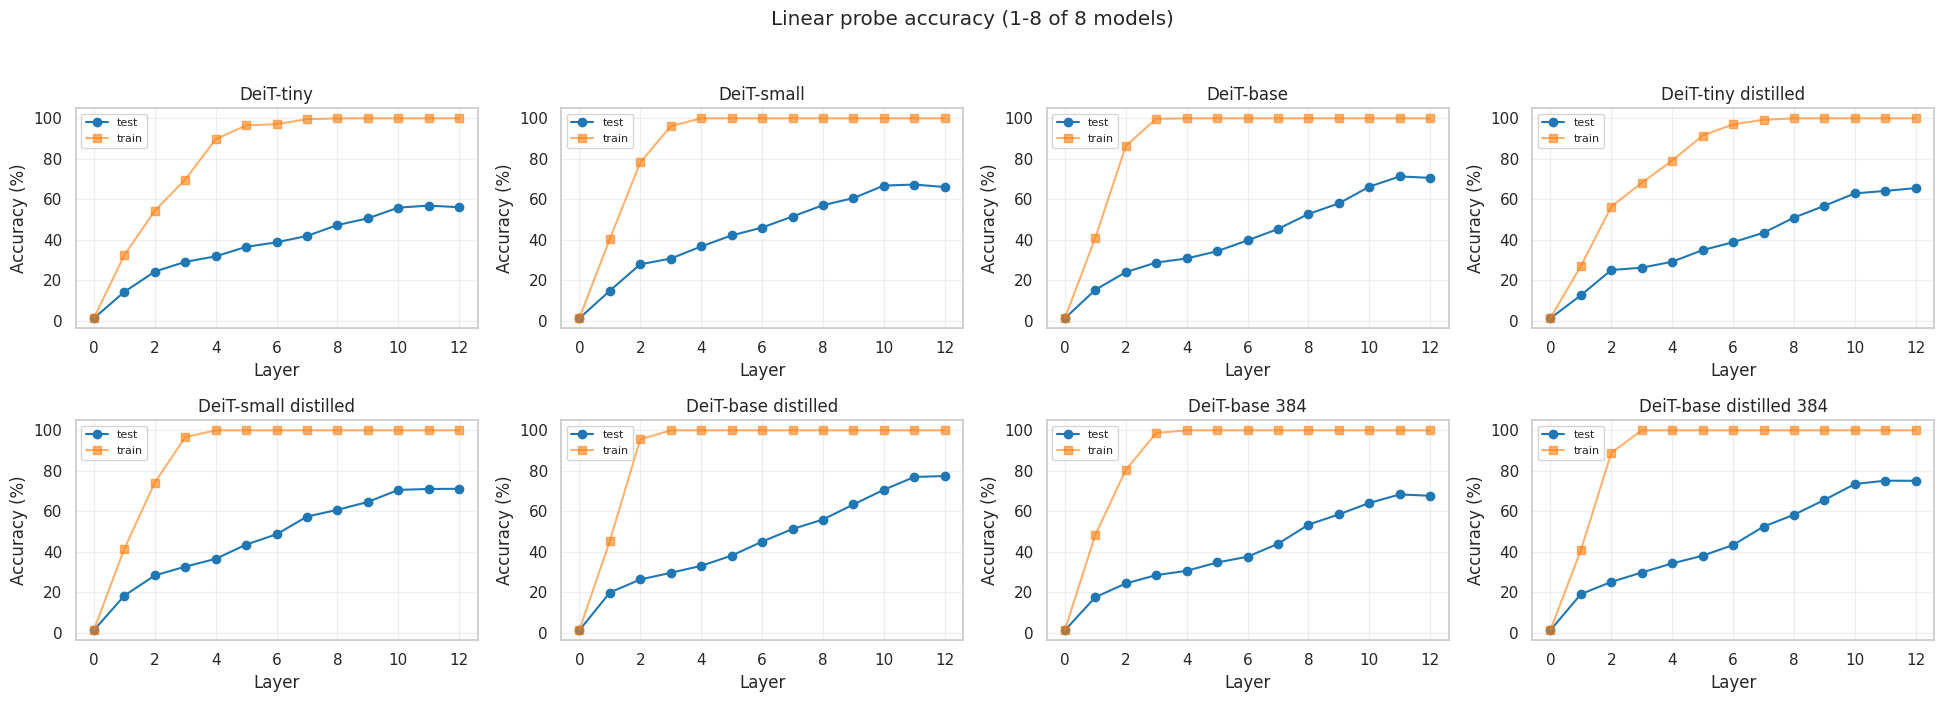

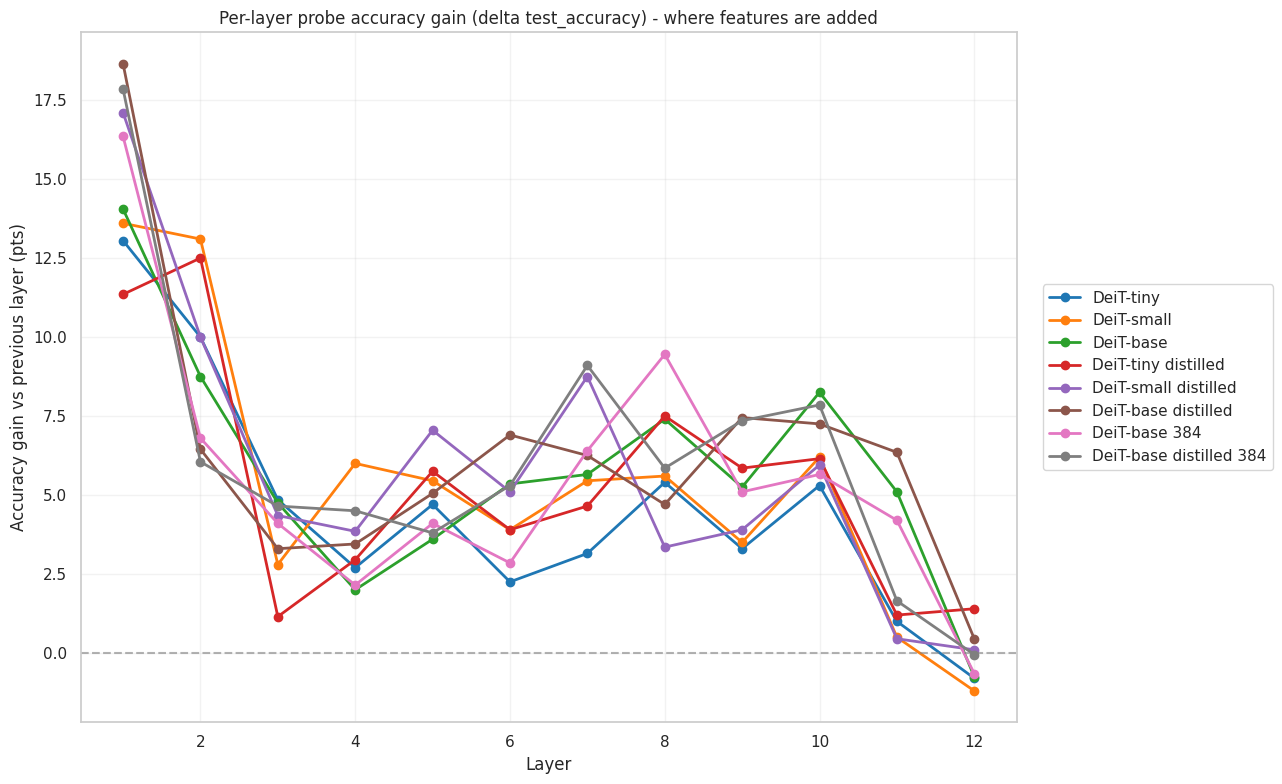

In [8]:
plot_probe_accuracy_comparison(probe_results_df, selected_specs, metric="test_accuracy")
plot_probe_report(probe_results_df, selected_specs)
plot_probe_layer_gain(probe_results_df, selected_specs, metric="test_accuracy")


In [9]:
results_dir = Path(EXPERIMENT_CONFIG["results_dir"])
probe_results_df = pd.read_csv(results_dir / "linear_probe_all_models.csv")
probe_results_df.head()


,model_name,repo_id,token_representation,layer,train_accuracy,test_accuracy,num_classes,train_size,test_size
0,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,0,1.27,1.15,100,4000,2000
1,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,1,32.35,14.20,100,4000,2000
2,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,2,54.30,24.20,100,4000,2000
3,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,3,69.73,29.05,100,4000,2000
4,DeiT-tiny,facebook/deit-tiny-patch16-224,cls,4,89.65,31.75,100,4000,2000
